<a href="https://www.kaggle.com/code/sohangdebnath/attention-unet-final?scriptVersionId=302120267" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
"""
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
"""

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nimport os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

In [2]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.notebook import tqdm

In [3]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"
device = torch.device(device)
print(device)

cuda:0


In [4]:
test_path = "/kaggle/input/massachusetts-buildings-dataset/png/test"
test_labels_path = "/kaggle/input/massachusetts-buildings-dataset/png/test_labels"
train_path = "/kaggle/input/massachusetts-buildings-dataset/png/train"
train_labels_path = "/kaggle/input/massachusetts-buildings-dataset/png/train_labels"
val_path = "/kaggle/input/massachusetts-buildings-dataset/png/val"
val_labels_path = "/kaggle/input/massachusetts-buildings-dataset/png/val_labels"

In [5]:
test = os.listdir(test_path)
test_label = os.listdir(test_labels_path)
train = os.listdir(train_path)
train_label = os.listdir(train_labels_path)
val = os.listdir(val_path)
val_label = os.listdir(val_labels_path)

In [6]:
print(f"Total test images : {len(test)}")
print(f"Total val images : {len(val)}")
print(f"Total train images : {len(train)}")

Total test images : 10
Total val images : 4
Total train images : 137


In [7]:
def showImages(image_path,label_path,title = "Sample"):
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("RGB")
    fig,ax = plt.subplots(1,2,figsize = (12,6))
    ax[0].imshow(image)
    ax[0].set_title(f"{title} Image")
    #ax[0].axis('off')
    ax[1].imshow(mask)
    ax[1].set_title(f"{title} Mask")
    plt.show()

In [8]:
img_path = "/kaggle/input/massachusetts-buildings-dataset/png/test/22828930_15.png"
mask_path = "/kaggle/input/massachusetts-buildings-dataset/png/test_labels/22828930_15.png"
showImages(img_path,mask_path)

In [9]:
COLOR_MAP ={
    (0,0,0):0, #surrounding
    (255,255,255):1 #buildings
}

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [11]:
class BuildingDataset(Dataset):
    def __init__(self, image_path, label_path, transform=None):
        self.image_path = image_path
        self.label_path = label_path
        self.transform = transform
        self.imgs = os.listdir(image_path)

        # label transform (NEAREST for segmentation masks!)
        self.label_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.NEAREST),
            transforms.PILToTensor()
        ])

    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        image = Image.open(os.path.join(self.image_path, img_name)).convert("RGB")
        label = Image.open(os.path.join(self.label_path, img_name)).convert("RGB")
        label = self.rgb_to_label(np.array(label))
        label = Image.fromarray(label.astype(np.uint8))

        if self.transform:
            image = self.transform(image)
        label = self.label_transform(label).squeeze(0)   # (H, W)

        return image, label.long()
    def rgb_to_label(self, label):
        label_mask = np.zeros(label.shape[:2], dtype=np.uint8)
        for color, value in COLOR_MAP.items():
            label_mask[np.all(label == color, axis=-1)] = value
        return label_mask

    def __get_original_image__(self, idx):
        img_name = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, img_name)
        image = Image.open(image_path).convert("RGB")
        return image

In [12]:
from torchvision.transforms import InterpolationMode

train_dataset = BuildingDataset(
    train_path, train_labels_path,train_transform
)
test_dataset = BuildingDataset(
    test_path, test_labels_path,test_transform
)
val_dataset = BuildingDataset(
    val_path, val_labels_path,test_transform
)

train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 4,shuffle = False)
val_loader = DataLoader(val_dataset,batch_size = 4,shuffle = False)

In [13]:
import torch
import torch.nn as nn

class Attention(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(Attention, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        out = x * psi
        return out


In [14]:
import torch
import torch.nn as nn

class Unet_with_attention(nn.Module):
    def __init__(self, num_classes):
        super(Unet_with_attention, self).__init__()
        self.contracting11 = self.conv_block(3, 64)
        self.contracting12 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.contracting21 = self.conv_block(64, 128)
        self.contracting22 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.contracting31 = self.conv_block(128, 256)
        self.contracting32 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.contracting41 = self.conv_block(256, 512)
        self.contracting42 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.middle = self.conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = self.conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = self.conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = self.conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = self.conv_block(128, 64)

        self.output = nn.Conv2d(64, num_classes, kernel_size=1)

        self.ag4 = Attention(512, 512, 256)
        self.ag3 = Attention(256, 256, 128)
        self.ag2 = Attention(128, 128, 64)
        self.ag1 = Attention(64, 64, 32)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(out_channels),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        c11 = self.contracting11(x)
        c12 = self.contracting12(c11)
        c21 = self.contracting21(c12)
        c22 = self.contracting22(c21)
        c31 = self.contracting31(c22)
        c32 = self.contracting32(c31)
        c41 = self.contracting41(c32)
        c42 = self.contracting42(c41)

        m = self.middle(c42)

        u4 = self.upconv4(m)
        g4 = self.ag4(u4, c41)
        u4 = self.conv4(torch.cat((u4, g4), dim=1))

        u3 = self.upconv3(u4)
        g3 = self.ag3(u3, c31)
        u3 = self.conv3(torch.cat((u3, g3), dim=1))

        u2 = self.upconv2(u3)
        g2 = self.ag2(u2, c21)
        u2 = self.conv2(torch.cat((u2, g2), dim=1))

        u1 = self.upconv1(u2)
        g1 = self.ag1(u1, c11)
        u1 = self.conv1(torch.cat((u1, g1), dim=1))

        out = self.output(u1)
        return out


In [15]:
num_classes = 2
model = Unet_with_attention(num_classes = num_classes).to(device)

In [16]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 1e-3)

In [17]:
def calculate_iou_dice(pred, target, num_classes=6):
    ious = []
    dices = []
    pred = pred.argmax(dim=1)  # [B, H, W] predicted class indices
    for cls in range(num_classes):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        
        iou = intersection / (union - intersection + 1e-6)
        dice = 2 * intersection / (union + 1e-6)
        
        ious.append(iou.item())
        dices.append(dice.item())
    return np.mean(ious), np.mean(dices)

In [18]:
IMG_SIZE = (224, 224)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

In [19]:
train_dataset = BuildingDataset(train_path, train_labels_path, transform=train_transform)
val_dataset   = BuildingDataset(val_path,   val_labels_path,   transform=val_transform)
test_dataset  = BuildingDataset(test_path,  test_labels_path,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False)


In [20]:
    # Store results in lists
    train_loss, val_loss, test_loss = [], [], []
    train_acc, val_acc, test_acc = [], [], []
    val_iou, test_iou = [], []
    val_dice, test_dice = [], []

In [21]:
# -----------------------
# Metric functions
# -----------------------
def iou_score_batch(preds, labels, num_classes):
    preds = preds.view(-1)
    labels = labels.view(-1)
    ious = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)
    return float(np.nanmean(ious))

def dice_score_batch(preds, labels, num_classes, eps=1e-8):
    preds = preds.view(-1)
    labels = labels.view(-1)
    dices = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = (pred_inds & target_inds).sum().item()
        denom = pred_inds.sum().item() + target_inds.sum().item()
        if denom == 0:
            dices.append(np.nan)
        else:
            dices.append((2.0 * intersection) / (denom + eps))
    return float(np.nanmean(dices))

def accuracy_score_batch(preds, labels):
    correct = (preds == labels).sum().item()
    total = labels.numel()
    return (correct / total)*100


# -----------------------
# Training loop
# -----------------------
def train_model(model, train_loader, val_loader, test_loader, num_epochs, device, num_classes, lr=1e-4):
    device = torch.device(device)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        # ----- TRAIN -----
        model.train()
        epoch_train_loss, epoch_train_acc = 0.0, 0.0
        for images, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            epoch_train_acc += accuracy_score_batch(preds, labels)

        train_loss.append(epoch_train_loss / len(train_loader))
        train_acc.append(epoch_train_acc / len(train_loader))

        # ----- VALIDATION -----
        model.eval()
        epoch_val_loss, epoch_val_iou, epoch_val_dice, epoch_val_acc = 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Val Epoch {epoch+1}"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                epoch_val_iou += iou_score_batch(preds, labels, num_classes)
                epoch_val_dice += dice_score_batch(preds, labels, num_classes)
                epoch_val_acc += accuracy_score_batch(preds, labels)

        val_loss.append(epoch_val_loss / len(val_loader))
        val_iou.append(epoch_val_iou / len(val_loader))
        val_dice.append(epoch_val_dice / len(val_loader))
        val_acc.append(epoch_val_acc / len(val_loader))

        # ----- TEST -----
        epoch_test_loss, epoch_test_iou, epoch_test_dice, epoch_test_acc = 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Test Epoch {epoch+1}"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_test_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                epoch_test_iou += iou_score_batch(preds, labels, num_classes)
                epoch_test_dice += dice_score_batch(preds, labels, num_classes)
                epoch_test_acc += accuracy_score_batch(preds, labels)

        test_loss.append(epoch_test_loss / len(test_loader))
        test_iou.append(epoch_test_iou / len(test_loader))
        test_dice.append(epoch_test_dice / len(test_loader))
        test_acc.append(epoch_test_acc / len(test_loader))

        # ----- PRINT -----
        if((epoch+1)%5==0):
            print("="*60)
            print(f"Epoch [{epoch+1}/{num_epochs}]")
            print(f" Train -> Loss: {train_loss[-1]:.4f} ")
            print(f" Val   -> Loss: {val_loss[-1]:.4f} | IoU: {val_iou[-1]:.4f} | Dice: {val_dice[-1]:.4f}")
            print(f" Test  -> Loss: {test_loss[-1]:.4f}  | IoU: {test_iou[-1]:.4f} | Dice: {test_dice[-1]:.4f}")
            print("="*60 + "\n")


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(COLOR_MAP)

In [23]:
train_model(model, train_loader, val_loader, test_loader, 50, device, num_classes, lr=1e-4)

Train Epoch 1:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 1:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 2:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 2:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 2:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 3:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 3:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 3:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 4:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 4:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 4:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 5:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 5:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 5:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [5/50]
 Train -> Loss: 0.6201 
 Val   -> Loss: 0.5586 | IoU: 0.5723 | Dice: 0.6953
 Test  -> Loss: 0.6022  | IoU: 0.5417 | Dice: 0.6857



Train Epoch 6:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 6:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 6:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 7:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 7:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 7:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 8:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 8:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 8:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 9:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 9:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 9:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 10:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 10:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 10:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [10/50]
 Train -> Loss: 0.5618 
 Val   -> Loss: 0.4989 | IoU: 0.6384 | Dice: 0.7502
 Test  -> Loss: 0.5322  | IoU: 0.6131 | Dice: 0.7418



Train Epoch 11:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 11:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 11:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 12:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 12:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 12:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 13:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 13:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 13:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 14:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 14:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 14:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 15:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 15:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 15:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [15/50]
 Train -> Loss: 0.5024 
 Val   -> Loss: 0.4332 | IoU: 0.6431 | Dice: 0.7531
 Test  -> Loss: 0.4866  | IoU: 0.6129 | Dice: 0.7400



Train Epoch 16:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 16:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 16:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 17:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 17:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 17:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 18:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 18:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 18:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 19:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 19:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 19:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 20:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 20:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 20:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [20/50]
 Train -> Loss: 0.4530 
 Val   -> Loss: 0.3859 | IoU: 0.6464 | Dice: 0.7525
 Test  -> Loss: 0.4347  | IoU: 0.5924 | Dice: 0.7124



Train Epoch 21:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 21:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 21:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 22:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 22:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 22:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 23:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 23:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 23:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 24:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 24:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 24:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 25:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 25:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 25:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [25/50]
 Train -> Loss: 0.4046 
 Val   -> Loss: 0.3182 | IoU: 0.6342 | Dice: 0.7387
 Test  -> Loss: 0.4247  | IoU: 0.5274 | Dice: 0.6397



Train Epoch 26:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 26:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 26:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 27:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 27:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 27:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 28:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 28:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 28:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 29:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 29:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 29:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 30:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 30:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 30:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [30/50]
 Train -> Loss: 0.3762 
 Val   -> Loss: 0.2805 | IoU: 0.6466 | Dice: 0.7517
 Test  -> Loss: 0.3834  | IoU: 0.5653 | Dice: 0.6809



Train Epoch 31:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 31:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 31:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 32:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 32:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 32:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 33:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 33:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 33:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 34:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 34:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 34:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 35:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 35:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 35:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [35/50]
 Train -> Loss: 0.3562 
 Val   -> Loss: 0.2681 | IoU: 0.5447 | Dice: 0.6301
 Test  -> Loss: 0.3721  | IoU: 0.5070 | Dice: 0.6084



Train Epoch 36:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 36:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 36:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 37:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 37:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 37:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 38:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 38:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 38:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 39:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 39:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 39:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 40:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 40:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 40:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [40/50]
 Train -> Loss: 0.3193 
 Val   -> Loss: 0.2176 | IoU: 0.6714 | Dice: 0.7762
 Test  -> Loss: 0.3122  | IoU: 0.6147 | Dice: 0.7339



Train Epoch 41:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 41:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 41:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 42:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 42:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 42:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 43:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 43:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 43:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 44:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 44:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 44:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 45:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 45:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 45:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [45/50]
 Train -> Loss: 0.3374 
 Val   -> Loss: 0.2069 | IoU: 0.6623 | Dice: 0.7666
 Test  -> Loss: 0.3304  | IoU: 0.5676 | Dice: 0.6819



Train Epoch 46:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 46:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 46:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 47:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 47:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 47:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 48:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 48:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 48:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 49:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 49:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 49:   0%|          | 0/3 [00:00<?, ?it/s]

Train Epoch 50:   0%|          | 0/35 [00:00<?, ?it/s]

Val Epoch 50:   0%|          | 0/1 [00:00<?, ?it/s]

Test Epoch 50:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch [50/50]
 Train -> Loss: 0.3277 
 Val   -> Loss: 0.2169 | IoU: 0.6402 | Dice: 0.7445
 Test  -> Loss: 0.3391  | IoU: 0.5762 | Dice: 0.6930



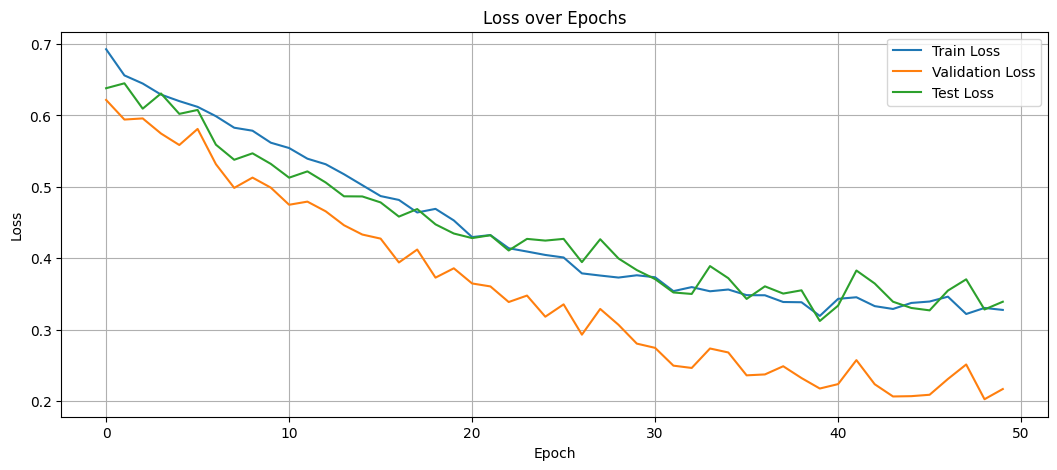

In [24]:
plt.figure(figsize=(28,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.show()


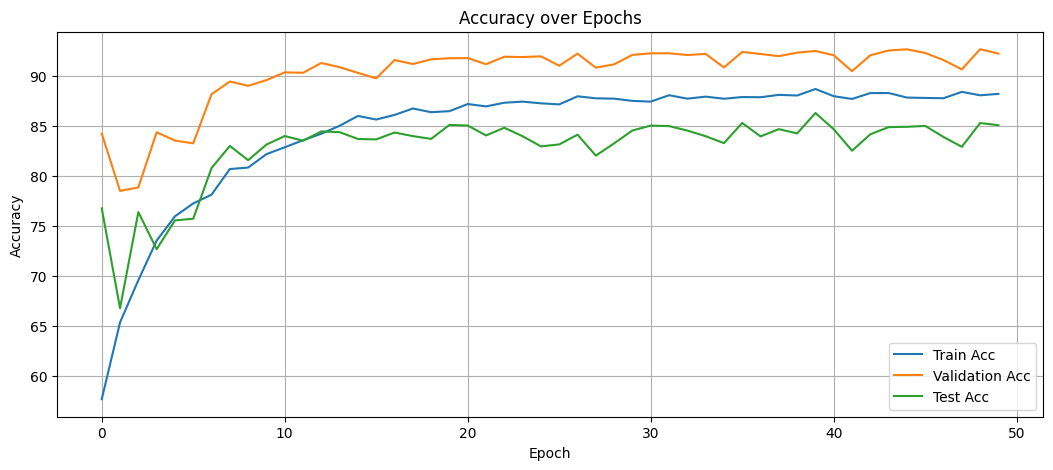

In [25]:
plt.figure(figsize=(28,5))
# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Validation Acc')
plt.plot(test_acc, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print("*"*60)
print(f"Final Training Accuracy = {train_acc[len(train_acc)-1]}")
print(f"Final Testing Accuracy = {test_acc[len(test_acc)-1]}")
print(f"Final Val Accuracy = {val_acc[len(val_acc)-1]}")
print("*"*60)

************************************************************
Final Training Accuracy = 88.18977200255101
Final Testing Accuracy = 85.05959024234694
Final Val Accuracy = 92.2183912627551
************************************************************


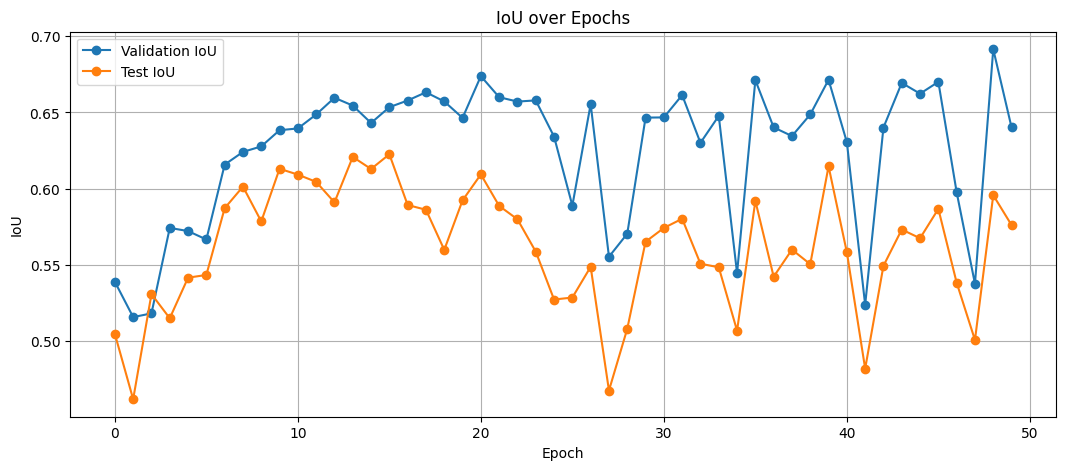

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(28,5))

# IoU plot
plt.subplot(1,2,1)
plt.plot(val_iou, label='Validation IoU', marker='o')
plt.plot(test_iou, label='Test IoU', marker='o')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('IoU over Epochs')
plt.legend()
plt.grid(True)

plt.show()


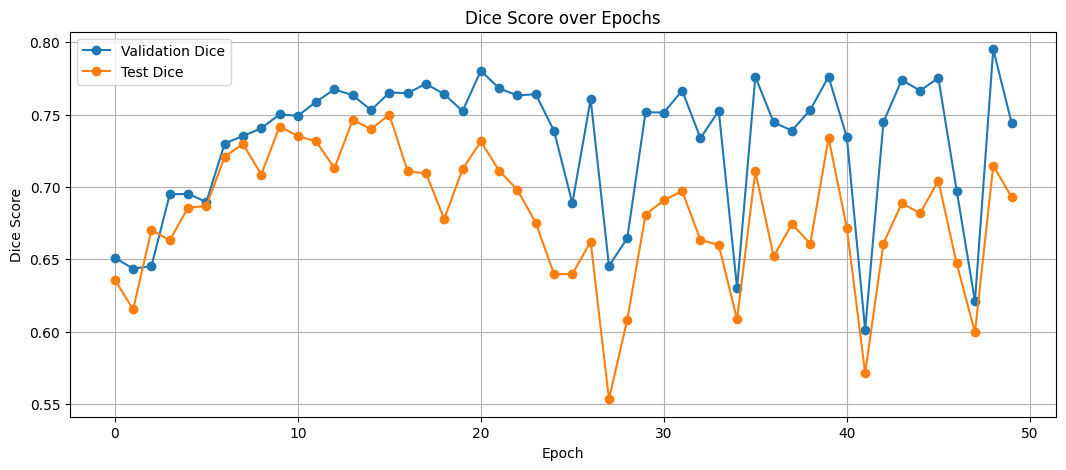

In [28]:
plt.figure(figsize=(28,5))
# Dice plot
plt.subplot(1,2,2)
plt.plot(val_dice, label='Validation Dice', marker='o')
plt.plot(test_dice, label='Test Dice', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.title('Dice Score over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
import matplotlib.pyplot as plt
import torch

def show_image_gt_pred(dataset, model, idx=0, device="cuda"):
    model.eval()
    
    # Get image and mask from dataset
    image, mask = dataset[idx]
    orig_img = image.permute(1,2,0).cpu().numpy( )  # convert CHW -> HWC for plotting
    
    # Add batch dimension and send to device
    image = image.unsqueeze(0).to(device)
    mask = mask.cpu().numpy()
    
    # Get prediction
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    # Plot original, ground truth, prediction
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(orig_img)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(orig_img)
    plt.imshow(pred, cmap="jet", alpha=0.5)  # using 'jet' for better visibility
    plt.title("Overlay (Image + Prediction)")
    plt.axis("off")
    
    plt.show()


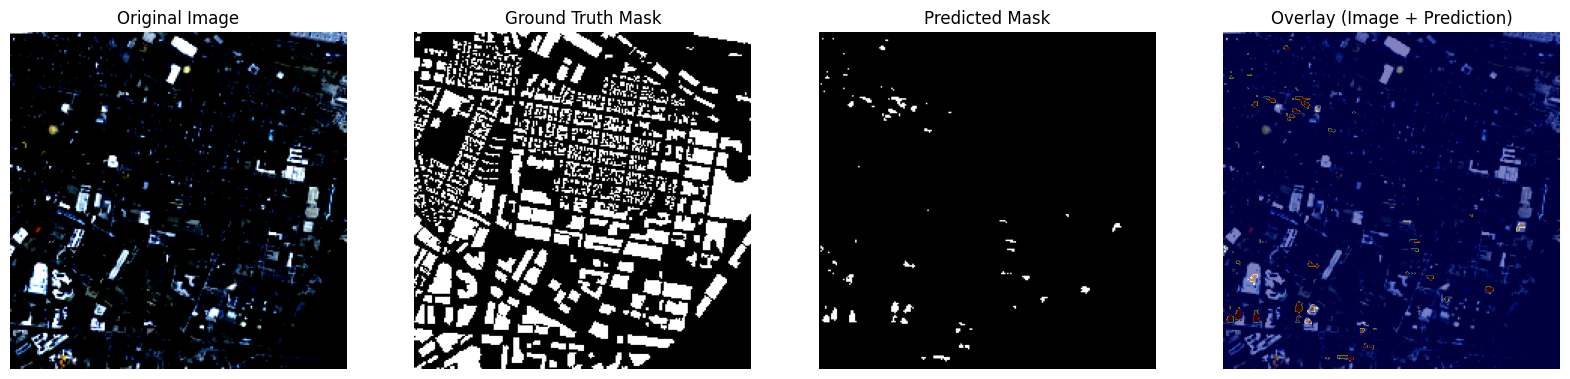

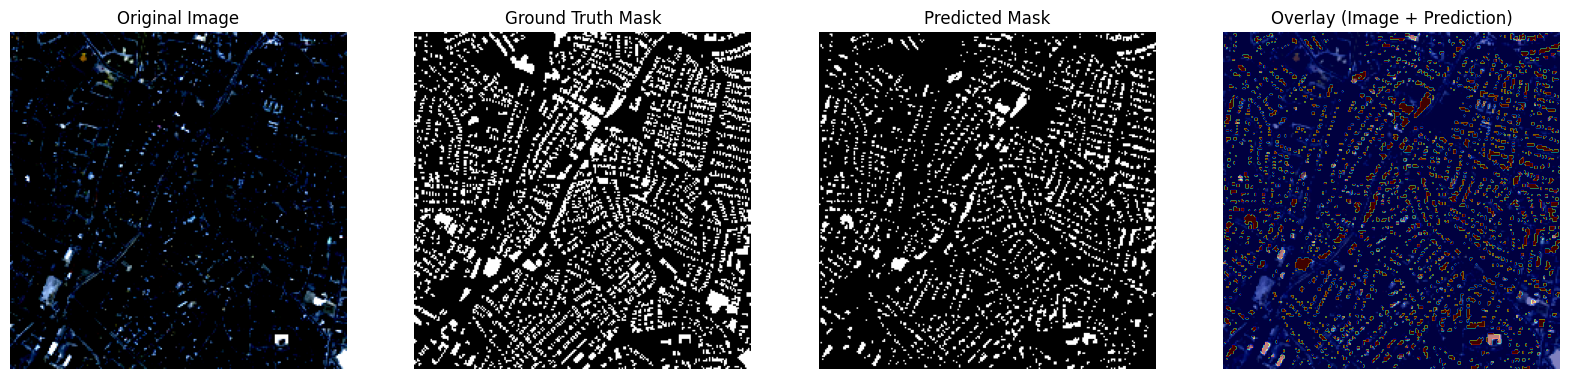

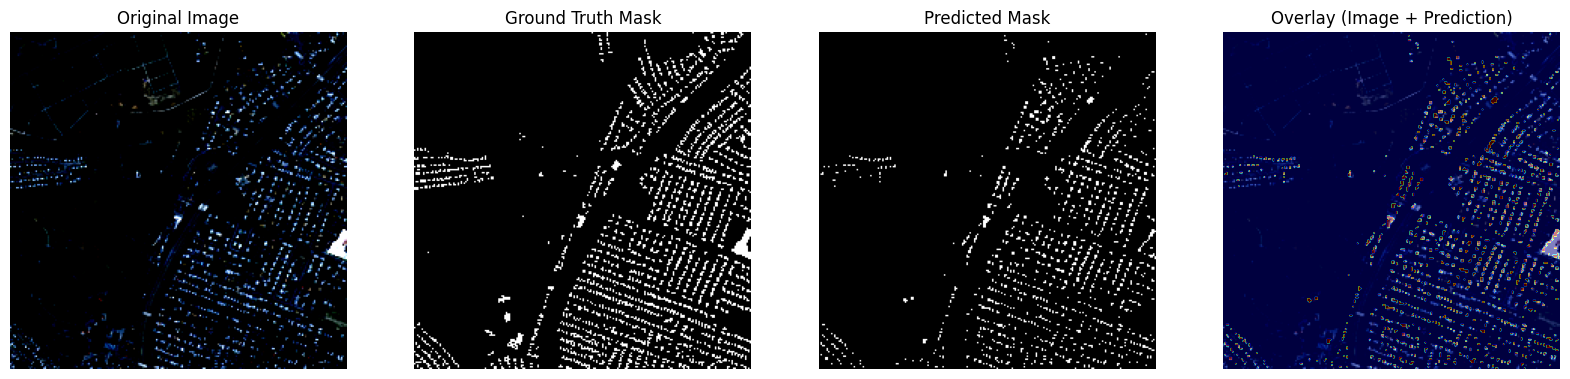

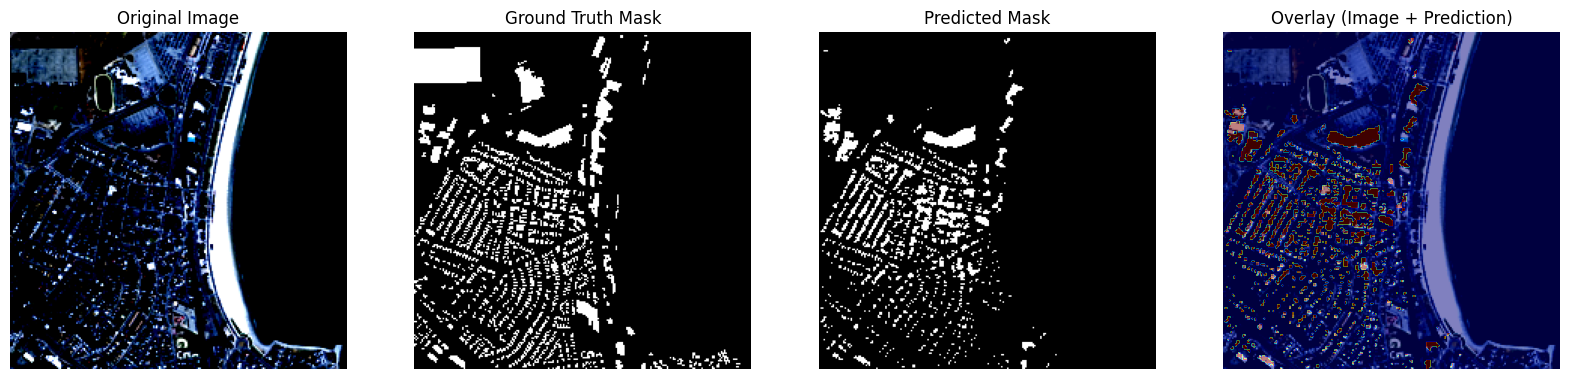

In [32]:
show_image_gt_pred(test_dataset, model, idx=1, device=device)
show_image_gt_pred(test_dataset, model, idx=2, device=device)
show_image_gt_pred(test_dataset, model, idx=3, device=device)
show_image_gt_pred(test_dataset, model, idx=4, device=device)

In [31]:
!pip install thop torchsummary
from thop import profile
from torchsummary import summary

# Example: Assume input is (3, 256, 256) for images
# Get a real batch to know the correct input size
sample_images, _ = next(iter(train_loader))
print("Sample input shape:", sample_images.shape)  
# e.g., torch.Size([16, 3, 256, 256]) → batch=16, channels=3, H=256, W=256

# Use one image (batch size 1) for profiling
dummy_input = torch.randn(1, sample_images.shape[1], sample_images.shape[2], sample_images.shape[3]).to(device)

flops, params = profile(model, inputs=(dummy_input, ))
print(f"Total Parameters: {params:,}")
print(f"FLOPs: {flops/1e9:.3f} GFLOPs")
print(f"Estimated Memory Size: {(params * 4) / (1024**2):.2f} MB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

ModuleNotFoundError: No module named 'thop'

In [ ]:
print(f"Total Parameters: {params:,}")
print(f"FLOPs: {flops/1e9:.3f} GFLOPs")
print(f"Estimated Memory Size: {(params * 4) / (1024**2):.2f} MB")


In [ ]:
# Fixed measure_dataloader (reset iterator after warmup)
import time, numpy as np, torch

def measure_dataloader(model, loader, device=None, warmup_batches=10, n_batches=None,
                       max_total_batches=1000, verbose=True):
    """
    Fixed version: resets iterator after warmup so measurement starts from beginning.
    Returns: numpy array of per-sample times (seconds).
    """
    # normalize device (simple)
    if isinstance(device, str):
        device = torch.device(device)
    elif device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        try:
            device = torch.device(str(device))
        except Exception:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Basic checks
    if loader is None:
        raise ValueError("loader is None. Provide a valid DataLoader.")
    try:
        loader_len = len(loader)
    except Exception:
        loader_len = None

    model = model.to(device)
    model.eval()

    times = []
    total_measured_batches = 0
    total_seen_batches = 0

    it = iter(loader)

    # Warmup: run some batches (wrap if loader shorter than warmup)
    with torch.inference_mode():
        for _ in range(warmup_batches):
            try:
                batch = next(it)
            except StopIteration:
                it = iter(loader)
                try:
                    batch = next(it)
                except StopIteration:
                    raise ValueError("DataLoader yielded no batches during warmup. Check dataset/transforms.")
            imgs = batch[0].to(device)
            _ = model(imgs)
        if device.type.startswith("cuda"):
            torch.cuda.synchronize()

    # IMPORTANT FIX: reset iterator so timed measurements start fresh
    it = iter(loader)

    # Timed measurement loop
    with torch.inference_mode():
        while True:
            if n_batches is not None and total_measured_batches >= n_batches:
                break
            if total_seen_batches >= max_total_batches:
                if verbose:
                    print(f"[measure_dataloader] reached max_total_batches={max_total_batches}, stopping.")
                break

            try:
                batch = next(it)
            except StopIteration:
                # iterator finished
                break

            imgs = batch[0].to(device)
            bs = imgs.size(0)
            if bs == 0:
                total_seen_batches += 1
                continue

            start = time.perf_counter()
            _ = model(imgs)
            if device.type.startswith("cuda"):
                torch.cuda.synchronize()
            end = time.perf_counter()

            batch_time = end - start
            times.append((batch_time, bs))
            total_measured_batches += 1
            total_seen_batches += 1

    if len(times) == 0:
        raise ValueError(
            "No batches were measured. Possible causes:\n"
            " - val_loader is empty or yields zero-sized batches,\n"
            " - warmup consumed all data and iterator exhausted before measurements (fixed by reset),\n"
            " - n_batches was set to 0.\n"
            "Check your DataLoader and try setting n_batches=1 for a quick test."
        )

    # Expand to per-sample times
    per_sample_times_list = [np.full(bs, (t / bs), dtype=float) for (t, bs) in times]
    per_sample_times = np.concatenate(per_sample_times_list).astype(float)

    if verbose:
        print(f"\n[measure_dataloader] device={device}, batches_measured={len(times)}, total_samples_measured={per_sample_times.size}")
        if loader_len is not None:
            print(f"[measure_dataloader] reported loader_len={loader_len}")
        print(f"[measure_dataloader] warmup_batches={warmup_batches}, requested_n_batches={n_batches}")

    return per_sample_times


In [ ]:
per_sample_times = measure_dataloader(model, val_loader, device=device, warmup_batches=5, n_batches=None)
print("median (ms):", np.median(per_sample_times)*1000)
print("p90 (ms):", np.percentile(per_sample_times, 90)*1000)
print("throughput (samples/sec):", 1.0 / per_sample_times.mean())
